# 🧩 Ejercicio 1 – Visualización de subestructuras dentro de un halo FoF

### Objetivo:
Visualizar las subestructuras (**subhalos**) dentro de un halo **FoF** seleccionado usando partículas de **materia oscura** y **estrellas** para la simulación **TNG100**.

---

## 🧭 Instrucciones:

1. Cargue las partículas de **materia oscura** y **estrellas** asociadas al **subhalo 10 ** (`subcenhid`).
2. Centre el sistema coordenado (0, 0, 0) en el **centro del halo FoF**.
3. Genere un gráfico de **2 paneles** de la distribución espacial (X-Y) de las partículas respecto al centro del subhalo:
   - **Primer panel**: partículas de **materia oscura**.
   - **Segundo panel**: partículas **estelares**.

---

## ❓ Preguntas:

- ¿Cuántos halos **FoF** tiene la simulación?
- ¿Cuál es el **ID de subhalo central** del **halo FoF 10**?
- ¿Las **subestructuras** se identifican claramente?
- ¿Cómo varía la **morfología** entre **materia oscura** y **estrellas**?

*Hint: cargue solo las **posiciones** de cada partícula*

In [2]:
import illustris_python as il 
import matplotlib.pyplot as plt
import numpy as np

In [3]:
#h = 0.6774
basePath = '../sims.TNG/TNG100-1/output/'
header = il.groupcat.loadHeader(basePath,99)
h = header['HubbleParam']
header

{'BoxSize': 75000.0,
 'FlagDoubleprecision': 0,
 'Git_commit': b'd203ec8b07c7e2bdda5f608aa0babea46d603699',
 'Git_date': b'Thu Apr 7 14:14:27 2016 +0200',
 'HubbleParam': 0.6774,
 'Ngroups_ThisFile': 1,
 'Ngroups_Total': 6291349,
 'Nids_ThisFile': 11830481,
 'Nids_Total': 5263038490,
 'Nsubgroups_ThisFile': 17185,
 'Nsubgroups_Total': 4371211,
 'NumFiles': 448,
 'Omega0': 0.3089,
 'OmegaLambda': 0.6911,
 'Redshift': 2.220446049250313e-16,
 'Time': 0.9999999999999998}

In [7]:
header = il.groupcat.loadHeader(basePath,99)
z = []

for i in range(99,0,-1):
    header = il.groupcat.loadHeader(basePath,i)
    z += [header['Redshift']]




In [21]:
z

[2.220446049250313e-16,
 0.009521666967944764,
 0.023974428382762536,
 0.0337243718735154,
 0.04852362998180593,
 0.058507322794512984,
 0.07366138465643868,
 0.08388443079747931,
 0.09940180263022191,
 0.10986994045882548,
 0.12575933241126092,
 0.14187620396956202,
 0.15274876890238098,
 0.1692520332436107,
 0.1803852617057493,
 0.19728418237600986,
 0.21442503551449454,
 0.22598838626019768,
 0.24354018155467028,
 0.2613432561610123,
 0.2733533465784399,
 0.2977176845174465,
 0.31007412012783386,
 0.32882972420595435,
 0.3478538418581776,
 0.36068765726181673,
 0.38016786726023866,
 0.3999269646135635,
 0.41996894199726653,
 0.4402978492477432,
 0.4609177941806475,
 0.4818329434209512,
 0.5030475232448832,
 0.524565820433923,
 0.5463921831410221,
 0.5759808451078874,
 0.5985432881875667,
 0.6214287452425136,
 0.6446418406845371,
 0.6761104112134777,
 0.7001063537185233,
 0.7326361820223115,
 0.7574413726158526,
 0.7910682489463392,
 0.8167099790118506,
 0.8514709006246495,
 0.886896

In [8]:
#CONSEGUIMOS LAS PARTÍCULAS DEL HALO con id = idHalo (Pedimos sus coordenadas y velocidades sólamente)
snapNum=99
idHalo = 10
fieldspart = ['Coordinates', 'Velocities']

Halo = il.snapshot.loadHalo(basePath, snapNum, idHalo, 'dm', fields=fieldspart)

#AHORA TENEMOS QUE ENCONTRAR CUAL ES EL ID DEL SUBHALO CENTRAL DE ESTE HALO FoF. 

#Recurrimos a las funciones del modulo groupcat, para acceder al catálogo de grupos. 
#Una de las variables almacenadas para cada Halo FoF, es el ID de subhalo de su subestructura central. Guardamos esa información de todos los halos 

GroupFirstSub = il.groupcat.loadHalos(basePath,snapNum,fields=['GroupFirstSub'])


print('Cuantos halos FoF tiene la simulación? Respuesta:', len(GroupFirstSub))
print('el ID de subhalo del subhalo central de el Halo ', idHalo,' es', GroupFirstSub[idHalo])
subcenhid = GroupFirstSub[idHalo]

Cuantos halos FoF tiene la simulación? Respuesta: 6291349
el ID de subhalo del subhalo central de el Halo  10  es 96500


In [9]:
field_subhalos = ['SubhaloCM','SubhaloGrNr','SubhaloMassType', 
                  'SubhaloMass', 'SubhaloPos','SubhaloVel']#campos a leer de la galaxia
fields_stars = ['Coordinates','Velocities'] #campos a leer de las estrellas

In [14]:
subhalos = il.groupcat.loadSubhalos(basePath,99,fields=field_subhalos)
shPos = subhalos['SubhaloPos']/h

In [15]:
gal = il.snapshot.loadSubhalo(basePath,99,id=10,partType=4,fields=fields_stars) #Lee las estrellas de la galaxia
galPos = gal['Coordinates']/h
pos=(galPos - shPos[10])

dm = il.snapshot.loadSubhalo(basePath,99,id=10,partType=1,fields=fields_stars) #Lee las part DM del subhalo
dmPos = dm['Coordinates']/h
dmpos=(dmPos - shPos[10])


<Figure size 640x480 with 0 Axes>

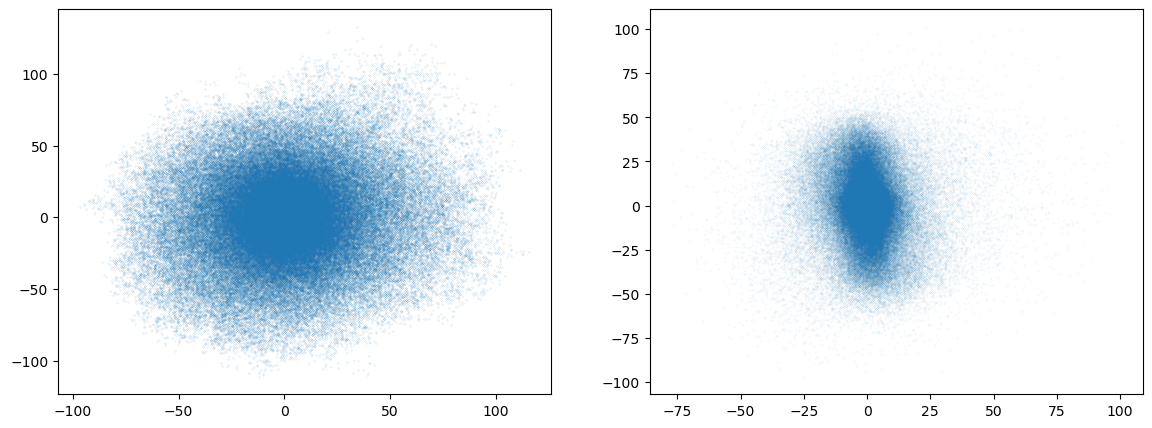

In [17]:
#Halo['Coordinates']
plt.figure()
fig, ax = plt.subplots(1,2,figsize=[14,5])
ax[0].scatter(dmpos[:,0],dmpos[:,1],s=0.01,alpha=0.7)
ax[1].scatter(pos[:,0],pos[:,1],s=0.01,alpha=0.3)
plt.show()

# 🧩 Ejercicio 2 – Evolución de masa a lo largo del redshift (árbol de formación)

### Objetivo:
Analizar cómo evoluciona la masa total de un halo a lo largo del tiempo cósmico (en función del **redshift**)  
utilizando el árbol de formación (**merger tree**) y considerando tres componentes: **materia oscura**, **gas** y **estrellas**.

---

## 🧭 Instrucciones:

1. Cargue el **árbol de formación** del subhalo central del **halo FoF 10** usando `onlyMPB=True`.
2. Obtenga las masas por tipo de partícula (`SubhaloMassType`) para cada snapshot del árbol.
3. Recupere el **redshift** correspondiente a cada snapshot.
4. Genere una figura que muestre la evolución de la masa de:
   - Materia oscura,
   - Gas,
   - Estrellas,

   en función del **redshift** (usar escala logarítmica en masa).

---

## ❓ Preguntas:

- ¿Cuál componente crece más rápido en la evolución temprana del halo?
- ¿La masa estelar sigue creciendo hasta z=0 o se estabiliza?
- ¿Cómo se compara el crecimiento del gas con el de materia oscura?

*Hint: use el catálogo del **merger tree** (Sublink) y extraiga `SubhaloMassType`, `SnapNum`, y `Redshift`*


In [1]:
import illustris_python as il 
import matplotlib.pyplot as plt
import numpy as np


snapNum=99
idHalo = 10

def get_redshift_vec(tree):
    z = []
    for i in range(len(tree)):
        z += [tree[i]]
        z += [il.groupcat.loadHeader(basePath,tree[i])['Redshift']]
    z = list(z)
    #z = np.reshape(z,[100,2])
    return z

h = 0.6774
basePath = '../sims.TNG/TNG100-1/output/'

GroupFirstSub = il.groupcat.loadHalos(basePath,snapNum,fields=['GroupFirstSub'])


In [2]:
il.groupcat.loadHeader(basePath,99)

{'BoxSize': 75000.0,
 'FlagDoubleprecision': 0,
 'Git_commit': b'd203ec8b07c7e2bdda5f608aa0babea46d603699',
 'Git_date': b'Thu Apr 7 14:14:27 2016 +0200',
 'HubbleParam': 0.6774,
 'Ngroups_ThisFile': 1,
 'Ngroups_Total': 6291349,
 'Nids_ThisFile': 11830481,
 'Nids_Total': 5263038490,
 'Nsubgroups_ThisFile': 17185,
 'Nsubgroups_Total': 4371211,
 'NumFiles': 448,
 'Omega0': 0.3089,
 'OmegaLambda': 0.6911,
 'Redshift': 2.220446049250313e-16,
 'Time': 0.9999999999999998}

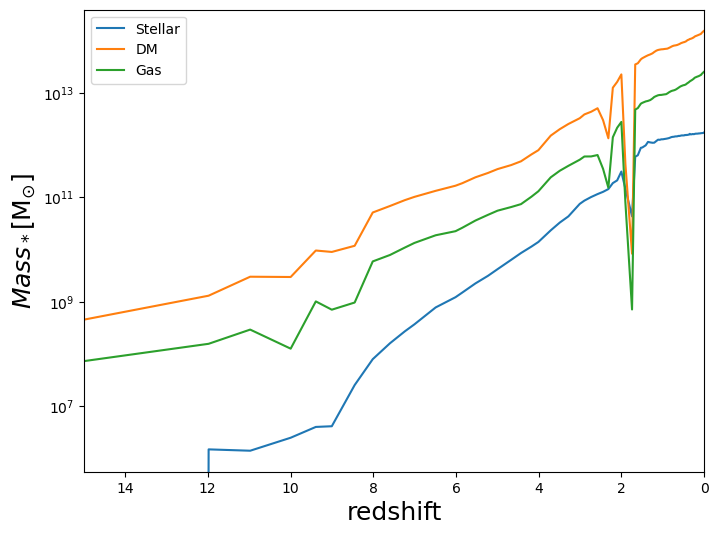

In [3]:
#Nota. En este ejemplo estamos graficando la masa total. En la práctica se pide graficar la masa estelar
    
fieldst = ['SubhaloMassType','SubfindID','SnapNum','NextProgenitorID']
snapNum = 99
idHalo = 10


    #Utilizamos la opción onlyMPB = True, porque sólo nos interesa 
    

tree = il.sublink.loadTree(basePath,snapNum,GroupFirstSub[idHalo],fields=fieldst,onlyMPB=False)     
    
fig, ax = plt.subplots(1,1,figsize=(8,6))

redshifts=[]
for snap in tree['SnapNum']:
    redshifts += [np.array([il.groupcat.loadHeader(basePath, snap)['Redshift']])]
    
ax.plot(redshifts,tree['SubhaloMassType'][:,4]*1e10/h,'-',label='Stellar')
ax.set_yscale('log')
ax.set_xlabel('redshift', fontsize=18)
ax.set(xlim=(max(redshifts),min(redshifts)))
ax.set_ylabel(r'$Mass_{\rm *} [{\rm M_{\odot}}]$',fontsize=18)
ax.plot(redshifts,tree['SubhaloMassType'][:,1]*1e10/h,'-',label='DM')
ax.plot(redshifts,tree['SubhaloMassType'][:,0]*1e10/h,'-',label='Gas')

plt.legend()
plt.show()

In [9]:
h = il.groupcat.loadHeader(basePath,99)['HubbleParam']

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

# Parámetros
basePath = '../sims.TNG/TNG100-1/output/'
snapNum = 99
halo_id = 10  # Ejemplo: halo de interés

# Cargar árbol extendido completo (notar: no usar onlyMPB)
tree = il.sublink.loadTree(basePath, snapNum, halo_id, onlyMPB=False)

# Crear mapa de SubhaloID -> índice
id_to_index = {sid: idx for idx, sid in enumerate(tree['SubhaloID'])}

# Recorrer main progenitor branch
index = 0
fpID = tree['FirstProgenitorID'][index]
host_masses = []
accretion_distances = []
snap_host = []
accretion_masses = []
hmr_h = []
a = []

while fpID != -1:
    index = id_to_index[fpID]

    # Cargar posición y masa del main progenitor
    snap_fp = tree['SnapNum'][index]
    subfp_id = tree['SubfindID'][index]
    pos_fp = il.groupcat.loadSingle(basePath, snap_fp, subhaloID=subfp_id)['SubhaloPos']
    hmr = il.groupcat.loadSingle(basePath, snap_fp, subhaloID=subfp_id)['SubhaloHalfmassRad']
    mvir_fp = il.groupcat.loadSingle(basePath, snap_fp, subhaloID=subfp_id)['SubhaloMass'] * 1e10 / 0.6774
    host_masses.append(mvir_fp)
    snap_host.append(snap_fp)
    hmr_h.append(hmr)
    a.append(il.groupcat.loadHeader(basePath,tree['SnapNum'][index])['Time'])
    if np.log10(mvir_fp) >= 8:
        # Recorrer NextProgenitors en este paso
        npID = tree['NextProgenitorID'][index]



        while npID != -1:
            if npID not in id_to_index:
                break  # Si el progenitor lateral no está, salta

            npIndex = id_to_index[npID]
            snap_np = tree['SnapNum'][npIndex]
            subnp_id = tree['SubfindID'][npIndex]
            pos_np = il.groupcat.loadSingle(basePath, snap_np, subhaloID=subnp_id)['SubhaloPos']
            mass_np = il.groupcat.loadSingle(basePath, snap_np, subhaloID=subnp_id)['SubhaloMass']
            # Calcular distancia y almacenar
            dist = np.linalg.norm(pos_np - pos_fp) / 0.6774  # kpc
            accretion_distances.append(dist)
            accretion_masses.append(mass_np * 1e10 / 0.6774)
            # Seguir a más next progenitors
            npID = tree['NextProgenitorID'][npIndex]

    # Avanzar al siguiente first progenitor
    fpID = tree['FirstProgenitorID'][index]

In [5]:
len(accretion_masses),len(accretion_distances), len(hmr_h)

(807, 807, 97)

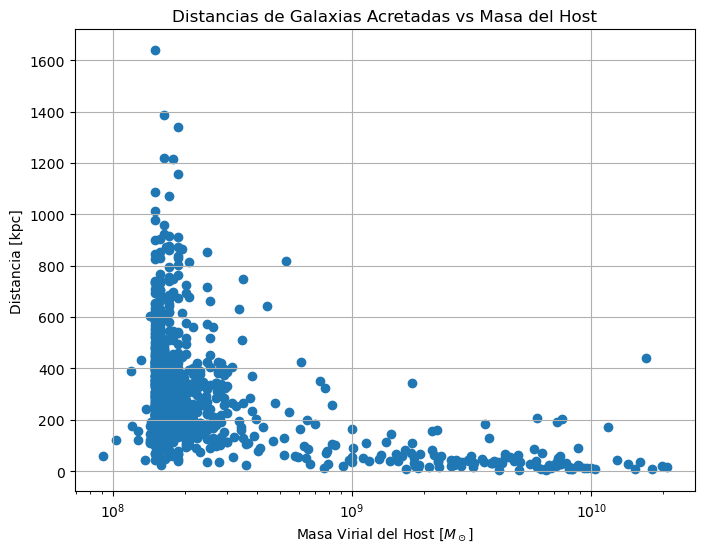

In [22]:
# Plot resultado
plt.figure(figsize=(8,6))
plt.scatter(accretion_masses, accretion_distances )
#plt.xlim(0,300)
plt.xlabel("Masa Virial del Host [$M_\odot$]")
plt.ylabel("Distancia [kpc]")
plt.xscale("log")
plt.title("Distancias de Galaxias Acretadas vs Masa")
plt.grid(True)
plt.show()


# 🧩 Ejercicio 3 – Diagramas fase y velocidad radial

### 🎯 Objetivo:
Explorar la **cinemática de las partículas estelares** en el halo seleccionado para detectar posibles estructuras dinámicas como **colas de marea** o **flujos coherentes**.

---

## 🧭 Instrucciones:

1. Cargue las **posiciones** y **velocidades** de las partículas estelares (`PartType4`) asociadas al subhalo central del halo.
2. Calcule la **velocidad radial** de cada partícula respecto al centro del halo.
3. Calcule la **distancia radial** de cada partícula al centro.
4. Construya el **diagrama de fase radial**: un scatter plot de **radio vs velocidad radial**.

---

## ❓ Preguntas:

- ¿Se observan **flujos coherentes** en alguna dirección radial?
- ¿Aparecen **colas de marea** o estructuras extendidas fuera del cuerpo principal del halo?
- ¿Alguna región del diagrama indica evidencia de **acreción reciente** de subhalos?

---

### ✅ Hint:
Para obtener la velocidad radial \( v_r \), use el producto escalar entre el vector de velocidad y la posición normalizada al radio:

$$
v_r = \frac{\vec{r} \cdot \vec{v}}{|\vec{r}|}
$$

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il

# Parámetros básicos
basePath = '../sims.TNG/TNG100-1/output/'
snapNum = 99
idHalo = 10

subhalo = il.groupcat.loadSubhalos(basePath, snapNum, fields=['SubhaloCM', 'SubhaloVel'])
center_pos = subhalo['SubhaloCM'][idHalo]/h
center_vel = subhalo['SubhaloVel'][idHalo]/h

# Cargar partículas estelares
stars = il.snapshot.loadSubhalo(basePath, snapNum, idHalo, 'stars', fields=['Coordinates', 'Velocities'])

coords = stars['Coordinates']/h
vels = stars['Velocities']/h

# Cargar centro del subhalo
center = il.groupcat.loadSubhalos(basePath, snapNum, fields=['SubhaloCM'])[idHalo]

# Centrar coordenadas y velocidades
r = coords - center_pos
v = vels - center_vel

# Calcular distancia radial
r_norm = np.linalg.norm(r, axis=1)

# Calcular velocidad radial (producto escalar entre r y v / |r|)
v_radial = np.sum(r * v, axis=1) / r_norm


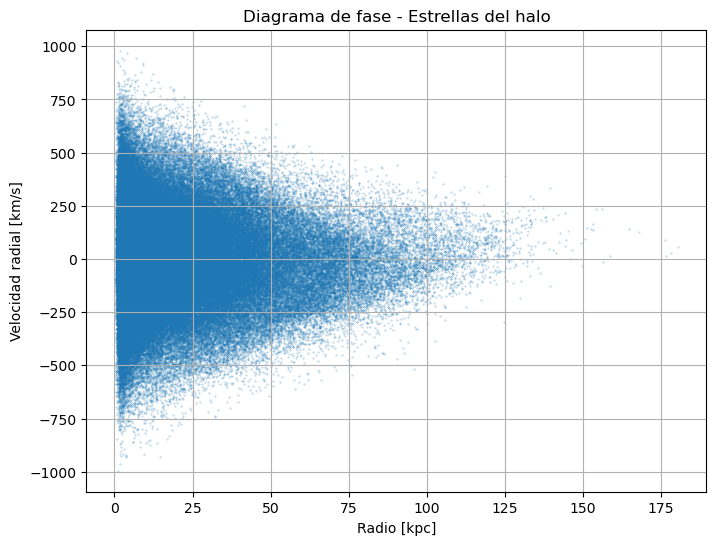

In [72]:
plt.figure(figsize=(8,6))
plt.scatter(r_norm,v_radial, s=0.1, alpha=0.5)
plt.xlabel("Radio [kpc]")
plt.ylabel("Velocidad radial [km/s]")
plt.title("Diagrama de fase - Estrellas del halo")
plt.grid(True)
plt.show()


# 🧩 Historia de Formación Estelar de un Halo en TNG100

## 🎯 Objetivo
Reconstruir la **historia de formación estelar** de un halo a lo largo de todos los snapshots,  
considerando los **subhalos asociados** al **mismo FoF halo** en cada snapshot.

## 🧭 Estrategia:
1. Recorrer **todos los snapshots disponibles**.
2. Para cada snapshot:
   - Buscar el **FoF halo por ID**,
   - Obtener **todos los subhalos del grupo** (`GroupFirstSub` y siguientes).
   - Obtener la **Historia de formación estelar de todos los subhalos del grupo**.

3. Graficar la **Historia de formación estelar** en función del **redshift**.

> *Este método permite incluir también las galaxias satélites del mismo grupo, y no solo el central.*
